<a href="https://colab.research.google.com/github/RocioDure12/ANALISIS_DENGUE_ARG/blob/main/TPI_FINAL_DENGUE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#TPI - Proyecto análisis de casos de dengue en Argentina
## Notebook completo y documentado paso a paso

##0. Librerias de trabajo

In [139]:
import pandas as pd
import os
import chardet
import numpy as np
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import math

##1. Carga de datos desde URLS (https://datos.gob.ar/)

In [140]:
datasets = {
    "dengue_2025_se1_38.csv": "http://datos.salud.gob.ar/dataset/ceaa8e87-297e-4348-84b8-5c643e172500/resource/937f34bc-dc3d-4fa1-bb0b-09a749a69d23/download/informacion-publica-dengue-zika-nacional-se-1-a-38-de-2025-2025-09-29.csv",
    "dengue_2024_v1.csv": "http://datos.salud.gob.ar/dataset/ceaa8e87-297e-4348-84b8-5c643e172500/resource/e57edd84-096d-4348-9137-2f5dae9c8f55/download/informacion-publica-dengue-zika-nacional-se-1-a-52-de-2024-2025-05-05.csv",
    "dengue_2024_v2.csv": "http://datos.salud.gob.ar/dataset/ceaa8e87-297e-4348-84b8-5c643e172500/resource/6ab1d526-afe2-4213-b216-ccb8369ef2f9/download/informacion-publica-dengue-zika-nacional-se-1-a-52-de-2024-2025-01-13.csv",
    "dengue_2024_v3.csv": "http://datos.salud.gob.ar/dataset/ceaa8e87-297e-4348-84b8-5c643e172500/resource/1b18a1ff-c381-4c3b-8498-8a34854690d0/download/informacion-publica-dengue-zika-nacional-se-1-a-52-de-2024-2025-01-06.csv",
    "dengue_2023.csv": "http://datos.salud.gob.ar/dataset/ceaa8e87-297e-4348-84b8-5c643e172500/resource/19075374-b180-48a0-aaaf-e0e44cd6816f/download/informacion-publica-dengue-zika-nacional-se-1-a-52-de-2023-2024-06-10.csv",
    "dengue_2022.csv": "http://datos.salud.gob.ar/dataset/ceaa8e87-297e-4348-84b8-5c643e172500/resource/30d76bcb-b8eb-4bf3-863e-c87d41724647/download/informacion-publica-dengue-zika-nacional-anio-2022.csv",
    "dengue_hasta_2022.xlsx": "http://datos.salud.gob.ar/dataset/ceaa8e87-297e-4348-84b8-5c643e172500/resource/8275ff70-94e5-4ee0-9cbb-630587daa618/download/1648473440-6ff92f5b32926ebfb17725a0ab8e991652470725-informacion-publica-dengue-zika-nacional-ha.xlsx",
    "dengue_hasta_2021.xlsx": "http://datos.salud.gob.ar/dataset/ceaa8e87-297e-4348-84b8-5c643e172500/resource/9a6eed8b-6951-4348-b96d-3330eff13b2f/download/informacion-publica-dengue-zika-nacional-hasta-20210731.xlsx",
    "dengue_hasta_2020.xlsx": "http://datos.salud.gob.ar/dataset/ceaa8e87-297e-4348-84b8-5c643e172500/resource/3e11a05a-8287-4954-ab08-f698dc0ff3e1/download/informacion-publica-dengue-zika-nacional-hasta-20201231_1.xlsx",
    "dengue_hasta_2019.xlsx": "http://datos.salud.gob.ar/dataset/ceaa8e87-297e-4348-84b8-5c643e172500/resource/ab93dc4b-4e6c-499b-9335-c548a701a870/download/informacion-publica-dengue-zika-nacional-hasta-20191231_3.xlsx",
    "dengue_hasta_2018.csv": "http://datos.salud.gob.ar/dataset/ceaa8e87-297e-4348-84b8-5c643e172500/resource/255440b0-d8b2-4247-87d2-91dfec29eb0f/download/informacion-publica-dengue-zika-nacional-hasta-20181231.csv",
    "vigilancia_2018_old.xls": "http://datos.salud.gob.ar/dataset/ceaa8e87-297e-4348-84b8-5c643e172500/resource/bdd4e662-42cf-47ee-b7b3-bc14f5acae2d/download/vigilancia-de-dengue-y-zika-201812.xls"
}
# ==========================================
# 2. DESCARGA CON WGET
# ==========================================
import pandas as pd
import os
import chardet

# 1. DEFINICIÓN DE CARPETA Y FUENTES
carpeta_datos = "datos_dengue_argentina"
if not os.path.exists(carpeta_datos):
    os.makedirs(carpeta_datos)
    print(f"📁 Carpeta creada: {carpeta_datos}")

archivo_final = os.path.join(carpeta_datos, "dengue_historico_unificado.csv")

# (Tu diccionario de datasets se mantiene igual, solo ajustamos la ruta al usarlo)

# ==========================================
# 2. DESCARGA INTELIGENTE (Solo si no existen)
# ==========================================
print("Iniciando descarga de archivos...")
for nombre, url in datasets.items():
    ruta_archivo = os.path.join(carpeta_datos, nombre)

    if os.path.exists(ruta_archivo) :
        continue # Saltamos si ya existe

    print(f"📥 Descargando: {nombre}")
    !wget -q --no-check-certificate "{url}" -O "{ruta_archivo}"



# ==========================================
# 3. CARGA Y UNIFICACIÓN
# ==========================================
# ===================================================
# 3. CARGA Y UNIFICACIÓN (CORREGIDO)
# ===================================================
if os.path.exists(archivo_final):
    print(f"\n✅ El archivo unificado ya existe en '{archivo_final}'. Cargando directamente...")
    df_historico = pd.read_csv(archivo_final)
else:
    print("\n🔄 Unificando archivos por primera vez...")
    lista_dfs = []
    # Diccionario de SEGURIDAD solo para el año
    unificar_anio = {
        'año': 'anio',
        'ano': 'anio',
        'anio_min': 'anio',
        'anio': 'anio'
    }


    for nombre in datasets.keys():
        ruta_archivo = os.path.join(carpeta_datos, nombre)
        try:
            if nombre.endswith('.csv'):
                with open(ruta_archivo, 'rb') as f:
                    rawdata = f.read(20000)
                    result = chardet.detect(rawdata)
                try:
                    df_temp = pd.read_csv(ruta_archivo, encoding=result['encoding'], sep=None, engine='python')
                except:
                    df_temp = pd.read_csv(ruta_archivo, encoding='latin-1', sep=None, engine='python')

            elif nombre.endswith(('.xlsx', '.xls')):
                df_temp = pd.read_excel(ruta_archivo)

            #Estandarizamos a minúsculas y limpiamos espacios vacíos
            df_temp.columns = df_temp.columns.str.lower().str.strip()
            #Renombramos SOLO la columna del año antes de guardarlo en la lista
            df_temp.rename(columns=unificar_anio, inplace=True)


            lista_dfs.append(df_temp)
            print(f"📊 {nombre}: {df_temp.shape[0]} filas.")

        except Exception as e:
            print(f"⚠️ Error al procesar {nombre}: {e}")

    # Concatenar y GUARDAR
    if lista_dfs:
        df_historico = pd.concat(lista_dfs, ignore_index=True, sort=False)
        df_historico.to_csv(archivo_final, index=False)
        print(f"\n💾 Guardado exitoso: {archivo_final}")
    else:
        df_historico = pd.DataFrame()


# ==========================================
# 4. RESULTADO FINAL
# ==========================================
print("-" * 30)
print(f"✅ PROCESO COMPLETADO")
print(f"Filas totales: {df_historico.shape[0]}")
print("-" * 30)
df_historico.head()


Iniciando descarga de archivos...

✅ El archivo unificado ya existe en 'datos_dengue_argentina/dengue_historico_unificado.csv'. Cargando directamente...
------------------------------
✅ PROCESO COMPLETADO
Filas totales: 143397
------------------------------


/tmp/ipykernel_2816/1145512409.py:55: DtypeWarning: Columns (0,1,3,5,7,10,11,12,13,14,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df_historico = pd.read_csv(archivo_final)


,id_depto_indec_residencia,departamento_residencia,id_prov_indec_residencia,provincia_residencia,anio,evento,id_grupo_etario,grupo_etario,sepi_min,cantidad,departamento_id,departamento_nombre,provincia_id,provincia_nombre,semanas_epidemiologicas,evento_nombre,grupo_edad_id,grupo_edad_desc,cantidad_casos
0,999,desconocido,99.0,desconocida,2025.0,Dengue,2.0,Posneonato (29 hasta 365 días),10.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,999,desconocido,99.0,desconocida,2025.0,Dengue,2.0,Posneonato (29 hasta 365 días),12.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,999,desconocido,99.0,desconocida,2025.0,Dengue,2.0,Posneonato (29 hasta 365 días),16.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,999,desconocido,99.0,desconocida,2025.0,Dengue,2.0,Posneonato (29 hasta 365 días),18.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,999,desconocido,99.0,desconocida,2025.0,Dengue,2.0,Posneonato (29 hasta 365 días),20.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##2. Revision inicial del dataset

In [141]:
df_historico = pd.read_csv('datos_dengue_argentina/dengue_historico_unificado.csv', low_memory=False)

print(f"✅ Dataset cargado correctamente: {len(df_historico)} filas.")

df_historico.info()


✅ Dataset cargado correctamente: 143397 filas.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143397 entries, 0 to 143396
Data columns (total 19 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id_depto_indec_residencia  126905 non-null  object 
 1   departamento_residencia    126902 non-null  object 
 2   id_prov_indec_residencia   126902 non-null  float64
 3   provincia_residencia       126902 non-null  object 
 4   anio                       143394 non-null  float64
 5   evento                     126902 non-null  object 
 6   id_grupo_etario            126902 non-null  float64
 7   grupo_etario               126902 non-null  object 
 8   sepi_min                   126902 non-null  float64
 9   cantidad                   126902 non-null  float64
 10  departamento_id            16492 non-null   object 
 11  departamento_nombre        16492 non-null   object 
 12  provincia_id               16492 non-nu

In [142]:
df_historico.head(10)

,id_depto_indec_residencia,departamento_residencia,id_prov_indec_residencia,provincia_residencia,anio,evento,id_grupo_etario,grupo_etario,sepi_min,cantidad,departamento_id,departamento_nombre,provincia_id,provincia_nombre,semanas_epidemiologicas,evento_nombre,grupo_edad_id,grupo_edad_desc,cantidad_casos
0,999,desconocido,99.0,desconocida,2025.0,Dengue,2.0,Posneonato (29 hasta 365 días),10.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,999,desconocido,99.0,desconocida,2025.0,Dengue,2.0,Posneonato (29 hasta 365 días),12.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,999,desconocido,99.0,desconocida,2025.0,Dengue,2.0,Posneonato (29 hasta 365 días),16.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,999,desconocido,99.0,desconocida,2025.0,Dengue,2.0,Posneonato (29 hasta 365 días),18.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,999,desconocido,99.0,desconocida,2025.0,Dengue,2.0,Posneonato (29 hasta 365 días),20.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,999,desconocido,99.0,desconocida,2025.0,Dengue,2.0,Posneonato (29 hasta 365 días),21.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,999,desconocido,99.0,desconocida,2025.0,Dengue,2.0,Posneonato (29 hasta 365 días),22.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,999,desconocido,99.0,desconocida,2025.0,Dengue,3.0,De 13 a 24 meses,18.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,999,desconocido,99.0,desconocida,2025.0,Dengue,3.0,De 13 a 24 meses,19.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,999,desconocido,99.0,desconocida,2025.0,Dengue,3.0,De 13 a 24 meses,20.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [143]:
df_historico.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_depto_indec_residencia,126905,184,021,5734,NaN,NaN,NaN,NaN,NaN,NaN,NaN
departamento_residencia,126902,421,Capital,7556,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id_prov_indec_residencia,126902.0,NaN,NaN,NaN,38.432751,31.586187,2.0,10.0,30.0,66.0,99.0
provincia_residencia,126902,25,Buenos Aires,23406,NaN,NaN,NaN,NaN,NaN,NaN,NaN
anio,143394.0,NaN,NaN,NaN,2023.423539,1.348973,2018.0,2024.0,2024.0,2024.0,2025.0
evento,126902,2,Dengue,126820,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id_grupo_etario,126902.0,NaN,NaN,NaN,8.223889,2.645474,1.0,6.0,9.0,10.0,13.0
grupo_etario,126902,15,De 45 a 65 años,18313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sepi_min,126902.0,NaN,NaN,NaN,13.758089,7.946913,1.0,9.0,13.0,17.0,52.0
cantidad,126902.0,NaN,NaN,NaN,15.049645,53.991362,1.0,1.0,3.0,9.0,2351.0


##3. Revisión específica de calidad de datos


###3.1 Valores faltantes

In [144]:
faltantes = df_historico.isna().sum().sort_values(ascending=False)
faltantes[faltantes > 0]

,0
grupo_edad_id,126907
cantidad_casos,126906
departamento_id,126905
grupo_edad_desc,126905
departamento_nombre,126905
provincia_nombre,126905
evento_nombre,126905
provincia_id,126905
semanas_epidemiologicas,126905
departamento_residencia,16495


###3.2 Duplicados

In [145]:
print('Filas iniciales:', df_historico.shape[0])
df_historico.drop_duplicates(inplace=True)
print('Filas después de eliminar duplicados:', df_historico.shape[0])
duplicados = df_historico.duplicated().sum()
print('Cantidad de filas duplicadas restantes:', duplicados)

Filas iniciales: 143397
Filas después de eliminar duplicados: 73953
Cantidad de filas duplicadas restantes: 0


##4. Limpieza y preprocesamiento

In [183]:
df_trabajo = df_historico.copy()


In [184]:
df_trabajo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 73953 entries, 0 to 143396
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_depto_indec_residencia  57482 non-null  object 
 1   departamento_residencia    57481 non-null  object 
 2   id_prov_indec_residencia   57481 non-null  float64
 3   provincia_residencia       57481 non-null  object 
 4   anio                       73952 non-null  float64
 5   evento                     57481 non-null  object 
 6   id_grupo_etario            57481 non-null  float64
 7   grupo_etario               57481 non-null  object 
 8   sepi_min                   57481 non-null  float64
 9   cantidad                   57481 non-null  float64
 10  departamento_id            16471 non-null  object 
 11  departamento_nombre        16471 non-null  object 
 12  provincia_id               16471 non-null  object 
 13  provincia_nombre           16471 non-null  object 

###4.1 Normalizacion básica del texto

In [147]:
df_trabajo.columns = df_trabajo.columns.str.lower().str.strip()
print(df_trabajo.columns.tolist())
df_trabajo.head()

['id_depto_indec_residencia', 'departamento_residencia', 'id_prov_indec_residencia', 'provincia_residencia', 'anio', 'evento', 'id_grupo_etario', 'grupo_etario', 'sepi_min', 'cantidad', 'departamento_id', 'departamento_nombre', 'provincia_id', 'provincia_nombre', 'semanas_epidemiologicas', 'evento_nombre', 'grupo_edad_id', 'grupo_edad_desc', 'cantidad_casos']


,id_depto_indec_residencia,departamento_residencia,id_prov_indec_residencia,provincia_residencia,anio,evento,id_grupo_etario,grupo_etario,sepi_min,cantidad,departamento_id,departamento_nombre,provincia_id,provincia_nombre,semanas_epidemiologicas,evento_nombre,grupo_edad_id,grupo_edad_desc,cantidad_casos
0,999,desconocido,99.0,desconocida,2025.0,Dengue,2.0,Posneonato (29 hasta 365 días),10.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,999,desconocido,99.0,desconocida,2025.0,Dengue,2.0,Posneonato (29 hasta 365 días),12.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,999,desconocido,99.0,desconocida,2025.0,Dengue,2.0,Posneonato (29 hasta 365 días),16.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,999,desconocido,99.0,desconocida,2025.0,Dengue,2.0,Posneonato (29 hasta 365 días),18.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,999,desconocido,99.0,desconocida,2025.0,Dengue,2.0,Posneonato (29 hasta 365 días),20.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


###4.2 Corrección de categorias inconsistentes

In [148]:
columnas_no_deseadas=['id_depto_indec_residencia', 'id_prov_indec_residencia', 'id_grupo_etario', 'departamento_id', 'provincia_id', 'grupo_edad_id']
def delete_columnas(df: pd.DataFrame) -> pd.Series:
  for columna in columnas_no_deseadas:
    if columna in df.columns:
      df.drop(columns=[columna], inplace=True)

delete_columnas(df_trabajo)
df_trabajo.head()


,departamento_residencia,provincia_residencia,anio,evento,grupo_etario,sepi_min,cantidad,departamento_nombre,provincia_nombre,semanas_epidemiologicas,evento_nombre,grupo_edad_desc,cantidad_casos
0,desconocido,desconocida,2025.0,Dengue,Posneonato (29 hasta 365 días),10.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
1,desconocido,desconocida,2025.0,Dengue,Posneonato (29 hasta 365 días),12.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
2,desconocido,desconocida,2025.0,Dengue,Posneonato (29 hasta 365 días),16.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN
3,desconocido,desconocida,2025.0,Dengue,Posneonato (29 hasta 365 días),18.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
4,desconocido,desconocida,2025.0,Dengue,Posneonato (29 hasta 365 días),20.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN


In [149]:
#Diccionario para unificar nombres de columnas
renombramiento={
    'departamento_residencia':'departamento_nombre',
    'provincia_residencia':'provincia_nombre',
    'cantidad':'cantidad_casos',
    'grupo_etario':'grupo_etario',
    'grupo_edad_desc':'grupo_etario',
    'sepi_min':'semana_epidemiologica',
    'semanas_epidemiologicas':'semana_epidemiologica',
    'evento':'evento_nombre',

}

df_trabajo.rename(columns=renombramiento, inplace=True)
df_trabajo = df_trabajo.T.groupby(level=0).first().T
df_trabajo.head()


,anio,cantidad_casos,departamento_nombre,evento_nombre,grupo_etario,provincia_nombre,semana_epidemiologica
0,2025.0,1.0,desconocido,Dengue,Posneonato (29 hasta 365 días),desconocida,10.0
1,2025.0,1.0,desconocido,Dengue,Posneonato (29 hasta 365 días),desconocida,12.0
2,2025.0,2.0,desconocido,Dengue,Posneonato (29 hasta 365 días),desconocida,16.0
3,2025.0,1.0,desconocido,Dengue,Posneonato (29 hasta 365 días),desconocida,18.0
4,2025.0,1.0,desconocido,Dengue,Posneonato (29 hasta 365 días),desconocida,20.0


###4.3 Conversion de variables numéricas

In [150]:
df_trabajo.info()
# Auditoría de Ingeniería: ¿Qué hay realmente en las columnas?

print("--- Auditoría de ANIO ---")
print(f"Valores únicos: {df_trabajo['anio'].unique()[:10]}...") # Vemos los primeros 10
print(f"Cantidad de Nulos: {df_trabajo['anio'].isnull().sum()}")

print("\n--- Auditoría de SEMANAS (La columna rebelde) ---")
# Buscamos valores que NO sean dígitos en la columna semanas
intrusos_semanas = df_trabajo[~df_trabajo['semana_epidemiologica'].astype(str).str.isnumeric()]['semana_epidemiologica'].unique()
print(f"Valores no numéricos detectados: {intrusos_semanas}")

<class 'pandas.core.frame.DataFrame'>
Index: 73953 entries, 0 to 143396
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   anio                   73952 non-null  object
 1   cantidad_casos         73951 non-null  object
 2   departamento_nombre    73952 non-null  object
 3   evento_nombre          73952 non-null  object
 4   grupo_etario           73952 non-null  object
 5   provincia_nombre       73952 non-null  object
 6   semana_epidemiologica  73952 non-null  object
dtypes: object(7)
memory usage: 6.5+ MB
--- Auditoría de ANIO ---
Valores únicos: [2025.0 2024.0 None 2023.0 2022.0 2021.0 2020.0 2019.0 2018.0]...
Cantidad de Nulos: 1

--- Auditoría de SEMANAS (La columna rebelde) ---
Valores no numéricos detectados: [10.0 12.0 16.0 18.0 20.0 21.0 22.0 19.0 9.0 11.0 13.0 14.0 17.0 6.0 8.0
 15.0 1.0 2.0 7.0 4.0 5.0 3.0 28.0 26.0 23.0 24.0 27.0 25.0 29.0 30.0 33.0
 47.0 32.0 45.0 51.0 35.0 43.0 31.0 

In [151]:
#Definimos las columnas que queremos transformar
columnas_numericas = ['anio', 'semana_epidemiologica', 'cantidad_casos']

for col in columnas_numericas:
    if col in df_trabajo.columns:
        # Paso A: Convertir a número forzado.
        # Lo que sea texto (como 'Dengue ') se convierte en NaN automáticamente.
        df_trabajo[col] = pd.to_numeric(df_trabajo[col], errors='coerce')

        # Paso B: Rellenar los nulos con 0.
        # No se puede tener una columna de enteros con huecos vacíos en Pandas.
        df_trabajo[col] = df_trabajo[col].fillna(0)

        # Paso C: Ahora sí, convertimos a entero (int)
        df_trabajo[col] = df_trabajo[col].astype(int)

df_trabajo = df_trabajo[df_trabajo['cantidad_casos'] >= 1]

print("✅ ¡Números normalizados! Ahora son enteros limpios.")
df_trabajo.head()



✅ ¡Números normalizados! Ahora son enteros limpios.


,anio,cantidad_casos,departamento_nombre,evento_nombre,grupo_etario,provincia_nombre,semana_epidemiologica
0,2025,1,desconocido,Dengue,Posneonato (29 hasta 365 días),desconocida,10
1,2025,1,desconocido,Dengue,Posneonato (29 hasta 365 días),desconocida,12
2,2025,2,desconocido,Dengue,Posneonato (29 hasta 365 días),desconocida,16
3,2025,1,desconocido,Dengue,Posneonato (29 hasta 365 días),desconocida,18
4,2025,1,desconocido,Dengue,Posneonato (29 hasta 365 días),desconocida,20


###4.4 Normalizacion por columna

In [152]:
print("Valores encontrados en la columna evento_nombre:")
print(df_trabajo['evento_nombre'].unique())

Valores encontrados en la columna evento_nombre:
['Dengue' 'Dengue durante la gestación' '4' '6' '9' '10' '11' '12' '13'
 '14' '15' '16' '17' '18' '19' '20' '21' '22' '23' '27' '24' '25' '26' '2'
 '3' '7' '8' '28' '29' '33' '37' '43' '5' '48' '52'
 'Enfermedad por Virus del Zika']


In [153]:
# 1. Primero, limpiamos la columna pasándola a string, quitando espacios y llevándola a MAYÚSCULAS
df_trabajo['evento_nombre'] = df_trabajo['evento_nombre'].astype(str).str.strip().str.upper()

# Función rápida para barrer tildes solo en esta columna y asegurar el match
def sacar_tildes_simple(texto):
    texto_norm = unicodedata.normalize('NFD', texto)
    return "".join(c for c in texto_norm if unicodedata.category(c) != 'Mn')

df_trabajo['evento_nombre'] = df_trabajo['evento_nombre'].apply(sacar_tildes_simple)

# 2. Ahora que está en formato 'DENGUE DURANTE LA GESTACION', aplicamos el diccionario
mapeo_dengue_final = {
    'DENGUE DURANTE LA GESTACION': 'DENGUE'
}
df_trabajo['evento_nombre'] = df_trabajo['evento_nombre'].replace(mapeo_dengue_final)

# 3. FILTRADO CRÍTICO: Nos quedamos SOLAMENTE con los registros que sean estrictamente 'DENGUE'
# Esto va a barrer de un plumazo el Zika, los números ('4', '6', etc.) y los vacíos.
df_trabajo = df_trabajo[df_trabajo['evento_nombre'] == 'DENGUE'].copy()

# 4. Reseteamos el índice para mantener tu regla de oro (empezar en 1)
df_trabajo = df_trabajo.reset_index(drop=True)
df_trabajo.index = df_trabajo.index + 1

# --- CONTROL DE CALIDAD FINAL ---
print("Valores únicos finales en la columna 'evento_nombre':")
print(df_trabajo['evento_nombre'].unique())

Valores únicos finales en la columna 'evento_nombre':
['DENGUE']


In [154]:
print(df_trabajo['departamento_nombre'].unique())

['desconocido' 'COMUNA 1' 'COMUNA 2' 'COMUNA 3' 'COMUNA 4' 'COMUNA 5'
 'COMUNA 6' 'COMUNA 7' 'COMUNA 8' 'COMUNA 9' 'COMUNA 10' 'COMUNA 11'
 'COMUNA 12' 'COMUNA 13' 'COMUNA 14' 'COMUNA 15' 'Almirante Brown'
 'Avellaneda' 'Azul' 'Bahía Blanca' 'Berazategui' 'Capitán Sarmiento'
 'Carlos Tejedor' 'Colón' 'Coronel de Marina L. Rosales' 'Escobar'
 'Esteban Echeverría' 'Florencio Varela' 'General Pueyrredón'
 'General San Martín' 'Hurlingham' 'Ituzaingó' 'José C. Paz' 'La Matanza'
 'Lanús' 'La Plata' 'Lomas de Zamora' 'Luján' 'Malvinas Argentinas'
 'Marcos Paz' 'Mercedes' 'Merlo' 'Moreno' 'Morón' 'Olavarría' 'Pergamino'
 'Pilar' 'Pinamar' 'Quilmes' 'Rojas' 'Salto' 'San Antonio de Areco'
 'San Fernando' 'San Isidro' 'San Miguel' 'San Nicolás' 'San Pedro'
 'San Vicente' 'Tigre' 'Tres de Febrero' 'Vicente López' 'Zárate'
 'Andalgalá' 'Belén' 'Capayán' 'Capital' 'Fray Mamerto Esquiú' 'La Paz'
 'Santa Rosa' 'Valle Viejo' 'Calamuchita' 'Cruz del Eje' 'General Roca'
 'Ischilín' 'Juárez Celman' 'Marc

In [155]:
#Departamentos
df_trabajo['departamento_nombre'] = df_trabajo['departamento_nombre'].astype(str).str.strip().str.title()
# 2. Eliminar valores basura conocidos
basura = ['++++++++++++', '2007', '#¡Valor!', '(En Blanco)', '*Sin Dato*', 'Desconocido', 'Nan']
df_trabajo['departamento_nombre'] = df_trabajo['departamento_nombre'].replace(basura, "No Informado")


def normalizar_texto(texto):
    if not isinstance(texto, str):
        return texto
    # 1. Quitar espacios extras al principio y final
    texto = texto.strip()
    # 2. Normalizar tildes: convierte 'é' en 'e', 'ñ' se mantiene si usas este método
    # Pero para máxima compatibilidad, pasamos a ASCII y removemos lo que sobra
    s = "".join(c for c in unicodedata.normalize('NFD', texto)
               if unicodedata.category(c) != 'Mn')
    return s.title() # Lo deja como 'Neuquen'

# Aplicamos la función a la columna
df_trabajo['departamento_nombre'] = df_trabajo['departamento_nombre'].apply(normalizar_texto)

# Chequeo final
print(df_trabajo['departamento_nombre'].unique())


['No Informado' 'Comuna 1' 'Comuna 2' 'Comuna 3' 'Comuna 4' 'Comuna 5'
 'Comuna 6' 'Comuna 7' 'Comuna 8' 'Comuna 9' 'Comuna 10' 'Comuna 11'
 'Comuna 12' 'Comuna 13' 'Comuna 14' 'Comuna 15' 'Almirante Brown'
 'Avellaneda' 'Azul' 'Bahia Blanca' 'Berazategui' 'Capitan Sarmiento'
 'Carlos Tejedor' 'Colon' 'Coronel De Marina L. Rosales' 'Escobar'
 'Esteban Echeverria' 'Florencio Varela' 'General Pueyrredon'
 'General San Martin' 'Hurlingham' 'Ituzaingo' 'Jose C. Paz' 'La Matanza'
 'Lanus' 'La Plata' 'Lomas De Zamora' 'Lujan' 'Malvinas Argentinas'
 'Marcos Paz' 'Mercedes' 'Merlo' 'Moreno' 'Moron' 'Olavarria' 'Pergamino'
 'Pilar' 'Pinamar' 'Quilmes' 'Rojas' 'Salto' 'San Antonio De Areco'
 'San Fernando' 'San Isidro' 'San Miguel' 'San Nicolas' 'San Pedro'
 'San Vicente' 'Tigre' 'Tres De Febrero' 'Vicente Lopez' 'Zarate'
 'Andalgala' 'Belen' 'Capayan' 'Capital' 'Fray Mamerto Esquiu' 'La Paz'
 'Santa Rosa' 'Valle Viejo' 'Calamuchita' 'Cruz Del Eje' 'General Roca'
 'Ischilin' 'Juarez Celman' 'Mar

In [156]:
#Provincias
print(df_trabajo['provincia_nombre'].unique())

['desconocida' 'CABA' 'Córdoba' 'Tucumán' 'Buenos Aires' 'Catamarca'
 'Corrientes' 'Chaco' 'Chubut' 'Entre Ríos' 'Formosa' 'La Pampa'
 'La Rioja' 'Mendoza' 'Misiones' 'Neuquén' 'Salta' 'San Juan' 'San Luis'
 'Santa Cruz' 'Santa Fe' 'Santiago del Estero' 'Tierra del Fuego' 'Jujuy'
 'Río Negro' '6' '2' '10' '22' '14' '18' '30' '34' '38' '42' '46' '50'
 '54' '66' '74' '78' '82' '90' '*sin dato*' '(en blanco)' 'DESCONOCIDA']


In [157]:

valores_invalidos_nombre_provincia = ['6', '2', '10' ,'22', '14', '18', '30', '34', '38' ,'42' ,'46' ,'50', '54', '58', '62', '66', '70', '74', '78', '82', '86', '90','None', 'Desconocida', '*Sin Dato*', '(En Blanco)', 'Nan', 'Null'
]

df_trabajo['provincia_nombre'] = df_trabajo['provincia_nombre'].astype(str).str.strip().str.title()
df_trabajo['provincia_nombre'] = df_trabajo['provincia_nombre'].replace(valores_invalidos_nombre_provincia, "No Informado")
print(df_trabajo['provincia_nombre'].unique())

['No Informado' 'Caba' 'Córdoba' 'Tucumán' 'Buenos Aires' 'Catamarca'
 'Corrientes' 'Chaco' 'Chubut' 'Entre Ríos' 'Formosa' 'La Pampa'
 'La Rioja' 'Mendoza' 'Misiones' 'Neuquén' 'Salta' 'San Juan' 'San Luis'
 'Santa Cruz' 'Santa Fe' 'Santiago Del Estero' 'Tierra Del Fuego' 'Jujuy'
 'Río Negro']


In [158]:
#Si provincia_nombre y departamento_nombre son igual a "no informado, se eliminan"
# 1Definimos la condición: que ambas sean "No Informado"
filas_a_eliminar = (df_trabajo['provincia_nombre'] == 'No Informado') & \
                   (df_trabajo['departamento_nombre'] == 'No Informado')

# 2. Contamos cuántas vamos a borrar (para ser autocríticos con el impacto en el dataset)
cantidad_eliminada = filas_a_eliminar.sum()
print(f"Se van a eliminar {cantidad_eliminada} filas sin datos geográficos.")

# 3. Filtramos el DataFrame conservando lo opuesto (usando el signo '~' que es NOT)
df_trabajo = df_trabajo[~filas_a_eliminar].copy()

# 4. Verificación
print(f"Nuevo tamaño del dataset: {df_trabajo.shape[0]} filas.")


Se van a eliminar 673 filas sin datos geográficos.
Nuevo tamaño del dataset: 72102 filas.


In [159]:
#Limpieza previa de la columna para asegurar el match con el diccionario
df_trabajo['grupo_etario'] = (df_trabajo['grupo_etario']
                              .astype(str)
                              .str.strip()
                              .str.upper()
                              .str.replace(r'\s+', ' ', regex=True)) # Elimina espacios dobles o múltiples

# Categorías unificadas
estandarizacion_rango_etario = {
    # Menores de 1 año (Unificados exactamente a '< 1 AÑO')
    'MENOR QUE 1 ANO': '< 1 AÑO',
    'MENOR QUE 1 AÑO': '< 1 AÑO',
    'MENOR A 1 AÑO': '< 1 AÑO',
    'MENOR A 1 ANO': '< 1 AÑO',
    'POSNEONATO (29 HASTA 365 DÍAS)': '< 1 AÑO',
    'POSNEONATO (29 HASTA 365 DIAS)': '< 1 AÑO',
    'NEONATO (HASTA 28 DIAS)': '< 1 AÑO',
    'NEONATO (HASTA 28 DÍAS)': '< 1 AÑO',

    # 1 a 4 años
    'DE 13 A 24 MESES': '1-4 AÑOS',
    'IGUAL A 1 AÑO': '1-4 AÑOS',
    'IGUAL A 1 ANO': '1-4 AÑOS',
    'DE 2 A 4 AÑOS': '1-4 AÑOS',
    'DE 2 A 4 ANOS': '1-4 AÑOS',

    # 5 a 14 años
    'DE 5 A 9 AÑOS': '5-9 AÑOS',
    'DE 5 A 9 ANOS': '5-9 AÑOS',
    'DE 10 A 14 AÑOS': '10-14 AÑOS',
    'DE 10 A 14 ANOS': '10-14 AÑOS',

    # 15 a 24 años (Se respeta tu criterio de porcentaje)
    'DE 15 A 19 ANOS': '15-19 AÑOS',
    'DE 15 A 19 AÑOS': '15-19 AÑOS',
    'DE 15 A 24 ANOS': '20-24 AÑOS',
    'DE 15 A 24 AÑOS': '20-24 AÑOS',
    'DE 20 A 24 ANOS': '20-24 AÑOS',
    'DE 20 A 24 AÑOS': '20-24 AÑOS',

    # Adultos
    'DE 25 A 34 ANOS': '25-34 AÑOS',
    'DE 25 A 34 AÑOS': '25-34 AÑOS',
    'DE 35 A 44 ANOS': '35-44 AÑOS',
    'DE 35 A 44 AÑOS': '35-44 AÑOS',
    'DE 45 A 64 AÑOS': '45-64 AÑOS',
    'DE 45 A 64 ANOS': '45-64 AÑOS',
    'DE 45 A 65 AÑOS': '45-64 AÑOS',
    'DE 45 A 65 ANOS': '45-64 AÑOS',

    # Mayores
    'MAYORES DE 65 ANOS': '>= 65 AÑOS',
    'MAYORES DE 65 AÑOS': '>= 65 AÑOS',
    'MAYOR DE 65 ANOS': '>= 65 AÑOS', # Corregido el doble espacio
    'MAYOR DE 65 AÑOS': '>= 65 AÑOS',
    'MAYOR O IGUAL DE 65 AÑOS': '>= 65 AÑOS',
    'MAYOR O IGUAL DE 65 ANOS': '>= 65 AÑOS',

    # Manejo de basura/nulos remanentes
    'NAN': 'No Informado',
    'NONE': 'No Informado',
    'SIN DATO': 'No Informado',
    'SIN ESPECIFICAR':'No Informado',
    'EDAD SIN ESP.':'No Informado',
    'SIN ESPECIFICAR':'No Informado',
    '8':'No Informado',
    '9':'No Informado',
    '10':'No Informado',
    '5':'No Informado',
    '4':'No Informado',
    '3':'No Informado',
    '6':'No Informado',
    '7':'No Informado',
    '11':'No Informado',
    '-':'No Informado',
    '1':'No Informado',
    '2':'No Informado',
    '0':'No Informado',


}

# 3. Aplicar el reemplazo
df_trabajo['grupo_etario'] = df_trabajo['grupo_etario'].replace(estandarizacion_rango_etario)

# 4. Control de calidad inmediato
print("Categorías resultantes finales:")
print(df_trabajo['grupo_etario'].unique())

Categorías resultantes finales:
['20-24 AÑOS' '45-64 AÑOS' '>= 65 AÑOS' '10-14 AÑOS' '5-9 AÑOS'
 '15-19 AÑOS' '25-34 AÑOS' '35-44 AÑOS' '1-4 AÑOS' '< 1 AÑO'
 'No Informado']


In [160]:
# 1. Función para limpiar texto (quita tildes y pasa a MAYÚSCULAS)
def limpiar_celda(valor):
    if not isinstance(valor, str):
        return valor
    # Descompone caracteres con tilde y elimina los acentos
    texto_norm = unicodedata.normalize('NFD', valor)
    texto_sin_tildes = "".join(c for c in texto_norm if unicodedata.category(c) != 'Mn')
    return texto_sin_tildes.upper().strip()

# 2. Aplicar la limpieza a TODO el dataset (solo a las columnas que sean de texto)
columnas_texto = df_trabajo.select_dtypes(include=['object', 'string']).columns
for col in columnas_texto:
    df_trabajo[col] = df_trabajo[col].apply(limpiar_celda)

# 3. Borrar filas donde el rango etario NO esté definido
# Ya que pasamos todo a mayúsculas, los nulos estandarizados que creamos antes serán 'NO INFORMADO'
# También cubrimos si queda algún 'NAN' o string vacío por las dudas
valores_invalidos_edad = ['NO INFORMADO', 'NAN', 'NONE', 'SIN DATO', '']
mask_edad_valida = ~df_trabajo['grupo_etario'].isin(valores_invalidos_edad) & df_trabajo['grupo_etario'].notna()

df_trabajo = df_trabajo[mask_edad_valida].copy()

# 4. Resetear el índice para que empiece en 1
df_trabajo = df_trabajo.reset_index(drop=True)
df_trabajo.index = df_trabajo.index + 1



In [161]:
df_trabajo.head()

,anio,cantidad_casos,departamento_nombre,evento_nombre,grupo_etario,provincia_nombre,semana_epidemiologica
1,2025,1,NO INFORMADO,DENGUE,20-24 ANOS,CABA,16
2,2025,1,NO INFORMADO,DENGUE,45-64 ANOS,CABA,2
3,2025,1,NO INFORMADO,DENGUE,>= 65 ANOS,CABA,17
4,2025,1,NO INFORMADO,DENGUE,10-14 ANOS,CORDOBA,11
5,2025,1,NO INFORMADO,DENGUE,45-64 ANOS,CORDOBA,10


In [162]:
def chequear_porcentaje_nulos(df: pd.DataFrame) -> pd.Series:

  print('\nPorcentaje de valores nulos por columna:')
  missing_values = df_trabajo.isnull().sum()
  missing_percentage = (missing_values / len(df_historico)) * 100
  display(pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage': missing_percentage}).sort_values(by='Missing Percentage', ascending=False))


  columnas_a_eliminar = missing_percentage[missing_percentage > 90].index
  df_trabajo.drop(columns=columnas_a_eliminar, inplace=True)
  print(f"Paso 1 completado: Borramos {len(columnas_a_eliminar)} columnas que estaban vacías.")

chequear_porcentaje_nulos(df_trabajo)


Porcentaje de valores nulos por columna:


,Missing Count,Missing Percentage
anio,0,0.0
cantidad_casos,0,0.0
departamento_nombre,0,0.0
evento_nombre,0,0.0
grupo_etario,0,0.0
provincia_nombre,0,0.0
semana_epidemiologica,0,0.0


Paso 1 completado: Borramos 0 columnas que estaban vacías.


###4.5 Revisión final después de la limpieza

In [163]:
print('Dimensión final del dataset limpio:', df_trabajo.shape)
df_trabajo.info()

Dimensión final del dataset limpio: (62120, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62120 entries, 1 to 62120
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   anio                   62120 non-null  int64 
 1   cantidad_casos         62120 non-null  int64 
 2   departamento_nombre    62120 non-null  object
 3   evento_nombre          62120 non-null  object
 4   grupo_etario           62120 non-null  object
 5   provincia_nombre       62120 non-null  object
 6   semana_epidemiologica  62120 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 3.3+ MB


##5. Análisis exploratorio de datos (EDA)
###En este bloque se trabaja  con tres variables principales del proyecto:
*   cantidad_casos
*   anio
*   semana_epidemiologica




###5.1 Estadísticas descriptivas generales

In [164]:
eda_vars = ['anio', 'cantidad_casos', 'semana_epidemiologica']
df_trabajo[eda_vars].describe().T


,count,mean,std,min,25%,50%,75%,max
anio,62120.0,2023.390583,1.301109,2018.0,2023.0,2024.0,2024.0,2025.0
cantidad_casos,62120.0,13.301980,52.958607,1.0,1.0,2.0,8.0,2351.0
semana_epidemiologica,62120.0,15.460496,9.349961,1.0,10.0,14.0,18.0,53.0


### 5.2 Medidas de tendencia central, posición y dispersión
####Calculo

In [165]:
resumen_eda = pd.DataFrame({
    'media': df_trabajo[eda_vars].mean(),
    'mediana': df_trabajo[eda_vars].median(),
    'std': df_trabajo[eda_vars].std(),
    'min': df_trabajo[eda_vars].min(),
    'q1': df_trabajo[eda_vars].quantile(0.25),
    'q3': df_trabajo[eda_vars].quantile(0.75),
    'max': df_trabajo[eda_vars].max(),
    'iqr': df_trabajo[eda_vars].quantile(0.75) - df_trabajo[eda_vars].quantile(0.25)
})
resumen_eda

,media,mediana,std,min,q1,q3,max,iqr
anio,2023.390583,2024.0,1.301109,2018,2023.0,2024.0,2025,1.0
cantidad_casos,13.301980,2.0,52.958607,1,1.0,8.0,2351,7.0
semana_epidemiologica,15.460496,14.0,9.349961,1,10.0,18.0,53,8.0


###5.3 Primeras visualizaciones (exploratorias)

#### Distribución de Casos de Dengue por Provincia (Top 5)

/tmp/ipykernel_2816/2365921025.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='provincia_nombre', y='porcentaje', data=top_n_provinces, palette='viridis')


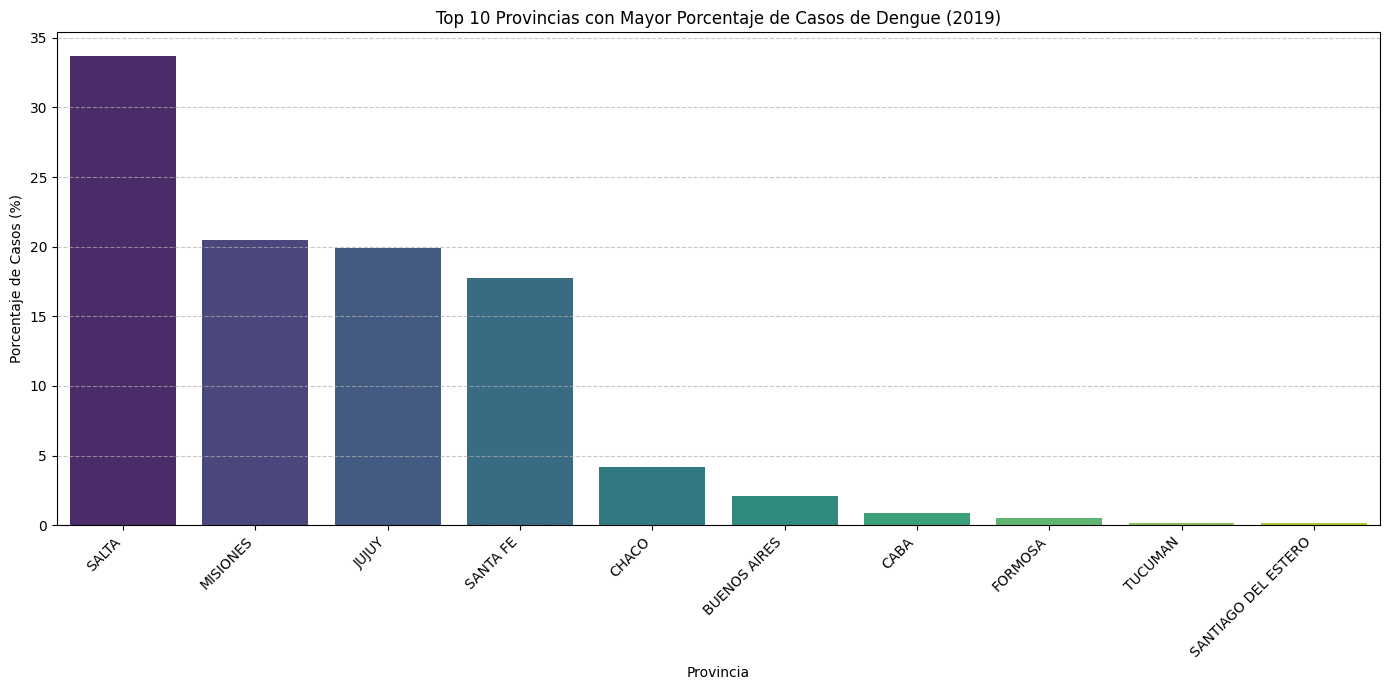

In [166]:

# @title Filtrar por años y seleccionar Top N provincias
selected_years = [2019] # @param
top_n = 10 # @param {type:"integer"}
ytick_interval = 5 # @param {type:"number"}

# Filtrar el DataFrame por los años seleccionados
df_filtered = df_trabajo[df_trabajo['anio'].isin(selected_years)].copy()

# Agrupar por provincia y sumar la cantidad de casos para los años seleccionados
cases_by_province_selected_years = df_filtered.groupby('provincia_nombre')['cantidad_casos'].sum().reset_index()

# Calcular el porcentaje de casos por provincia para los años seleccionados
total_cases_selected_years = cases_by_province_selected_years['cantidad_casos'].sum()
cases_by_province_selected_years['porcentaje'] = (cases_by_province_selected_years['cantidad_casos'] / total_cases_selected_years) * 100

# Obtener el top N de provincias
top_n_provinces = cases_by_province_selected_years.nlargest(top_n, 'cantidad_casos')

# Crear el gráfico de barras con porcentajes para el top N
plt.figure(figsize=(14, 7))
ax = sns.barplot(x='provincia_nombre', y='porcentaje', data=top_n_provinces, palette='viridis')

plt.title(f'Top {top_n} Provincias con Mayor Porcentaje de Casos de Dengue ({', '.join(map(str, selected_years))})')
plt.xlabel('Provincia')
plt.ylabel('Porcentaje de Casos (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Set y-axis ticks to show increments defined by ytick_interval
max_percentage = top_n_provinces['porcentaje'].max()
plt.yticks(np.arange(0, np.ceil(max_percentage / ytick_interval) * ytick_interval + 1, ytick_interval))


plt.tight_layout()
plt.show()

####Agrupar por año y semana epidemiológica

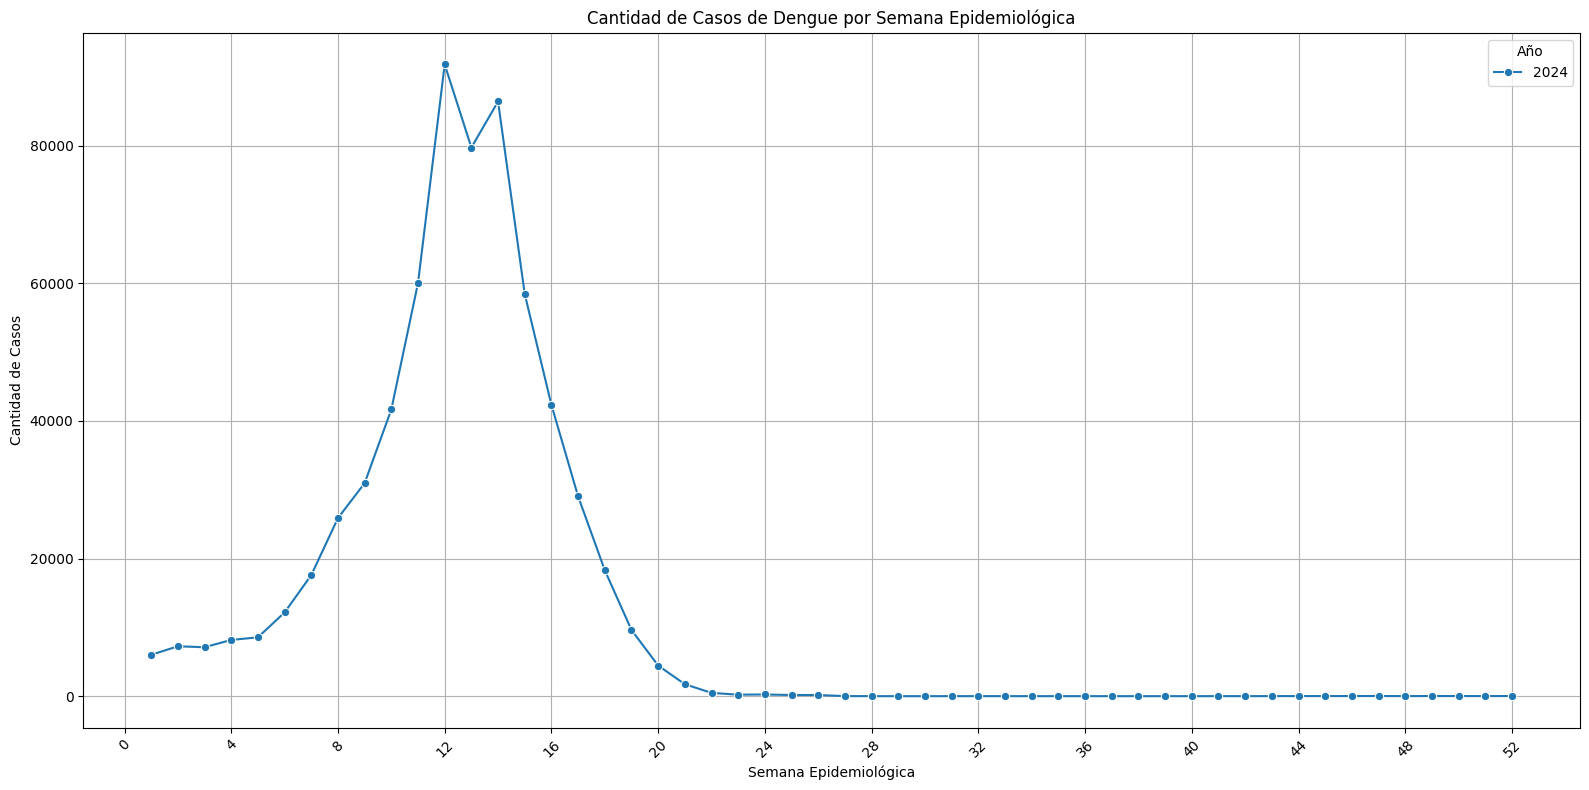

In [167]:
years = [2024] # @param
# Agrupar por año y semana epidemiológica y sumar la cantidad de casos
cases_by_year_week = df_trabajo[df_trabajo['anio'].isin(years)].groupby(['anio', 'semana_epidemiologica'])['cantidad_casos'].sum().reset_index()

# Crear el gráfico de líneas para todos los años
plt.figure(figsize=(16, 8))
sns.lineplot(x='semana_epidemiologica', y='cantidad_casos', hue='anio', data=cases_by_year_week, marker='o', palette='tab10')

plt.title('Cantidad de Casos de Dengue por Semana Epidemiológica')
plt.xlabel('Semana Epidemiológica')
plt.ylabel('Cantidad de Casos')
plt.grid(True)

# Set x-axis ticks to show increments of 4
xticks = 4
plt.xticks(np.arange(0, cases_by_year_week['semana_epidemiologica'].max() + xticks, xticks), rotation=45)

plt.legend(title='Año')
plt.tight_layout()
plt.show()

###5.3 Revisión de outliers

In [168]:
q1 = df_trabajo['cantidad_casos'].quantile(0.25)
q3 = df_trabajo['cantidad_casos'].quantile(0.75)
iqr = q3 - q1

lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

outliers_cantidad_casos = df_trabajo[(df_trabajo['cantidad_casos'] < lim_inf) | (df_trabajo['cantidad_casos'] > lim_sup)]
print('Cantidad de posibles outliers en cantidad_total:', outliers_cantidad_casos.shape[0])
outliers_cantidad_casos[['anio', 'semana_epidemiologica', 'cantidad_casos']].head(10)

Cantidad de posibles outliers en cantidad_total: 8350


,anio,semana_epidemiologica,cantidad_casos
632,2025,11,26
633,2025,12,20
652,2025,11,21
654,2025,13,19
655,2025,14,20
672,2025,11,28
673,2025,12,26
674,2025,13,27
675,2025,14,31
676,2025,15,19


In [169]:
outliers_cantidad_casos[['anio', 'semana_epidemiologica', 'cantidad_casos']].sort_values(by='cantidad_casos', ascending=False).head(10)

,anio,semana_epidemiologica,cantidad_casos
15376,2024,14,2351
37899,2024,14,2349
15015,2024,14,2108
38542,2024,14,2102
37902,2024,14,2101
38524,2024,12,1939
13815,2024,12,1938
13201,2024,13,1934
37906,2024,13,1932
38547,2024,12,1787


###5.4 Revisión por categorias


In [170]:
# Agrupa los datos por año y calcula métricas clave de 'cantidad_casos'
# (Total de reportes, promedio, mediana y la suma total de casos por año)

resumen_anual = df_trabajo.groupby('anio')['cantidad_casos'].agg(['count', 'mean', 'median', 'sum']).reset_index()
resumen_anual

,anio,count,mean,median,sum
0,2018,1495,1.816722,1.0,2716
1,2019,1262,2.202853,1.0,2780
2,2021,2304,3.400174,2.0,7834
3,2022,292,2.743151,1.0,801
4,2023,18019,8.123758,2.0,146382
5,2024,35810,18.117453,3.0,648786
6,2025,2938,5.793057,1.0,17020


###5.5 Asociación entre variables númericas

In [171]:
df_trabajo[['anio', 'cantidad_casos', 'semana_epidemiologica']].corr()

,anio,cantidad_casos,semana_epidemiologica
anio,1.000000,0.074507,-0.171767
cantidad_casos,0.074507,1.000000,-0.051582
semana_epidemiologica,-0.171767,-0.051582,1.000000


##Visualizaciones

### 6.1 Evolución anual de casos de dengue
Visualizamos el total de casos reportados por año para identificar tendencias generales.

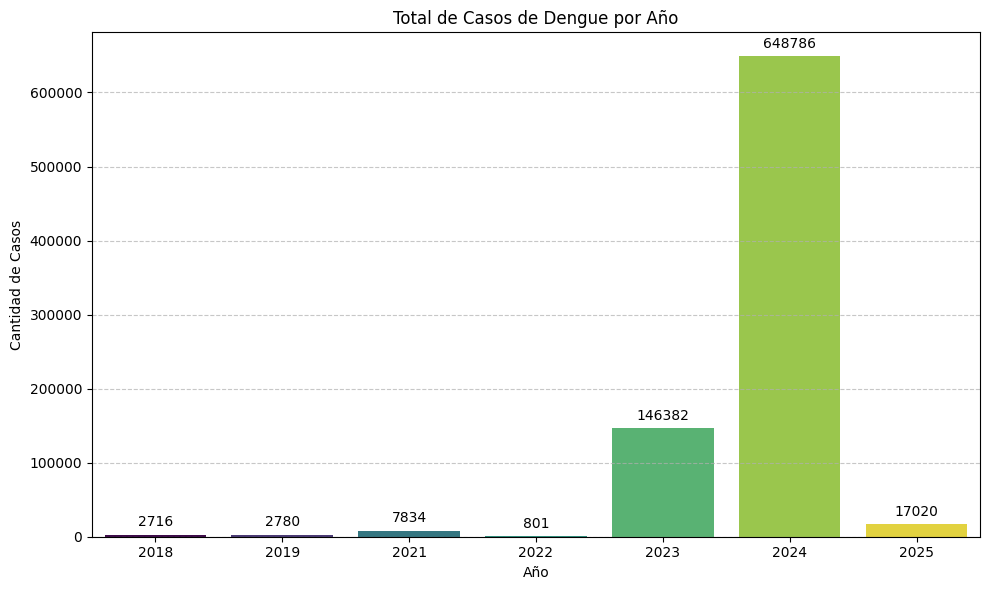

In [173]:
# Agrupar por año y sumar casos
casos_por_anio = df_trabajo.groupby('anio')['cantidad_casos'].sum().reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='anio', y='cantidad_casos', data=casos_por_anio, palette='viridis', hue='anio', legend=False)

# Añadir etiquetas de datos sobre las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.title('Total de Casos de Dengue por Año')
plt.xlabel('Año')
plt.ylabel('Cantidad de Casos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



###6.2 Distribución de casos por semana epidemiológica

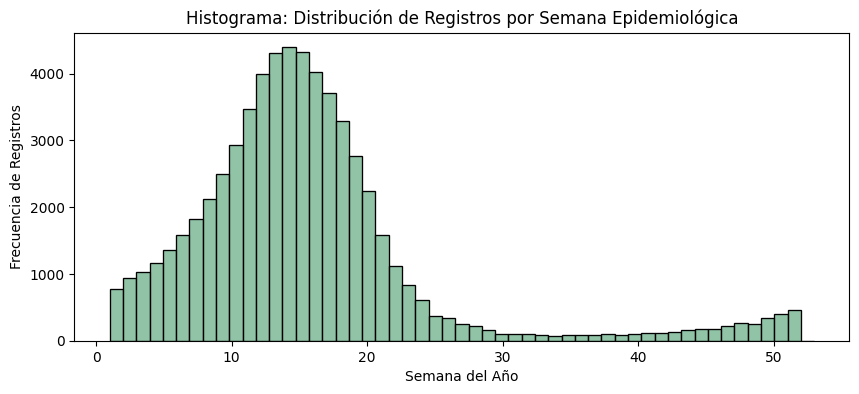

In [174]:
# Histograma para las semanas
plt.figure(figsize=(10, 4))
sns.histplot(df_trabajo['semana_epidemiologica'], bins=53, kde=False, color='#6DB08A')
plt.title('Histograma: Distribución de Registros por Semana Epidemiológica')
plt.xlabel('Semana del Año')
plt.ylabel('Frecuencia de Registros')
plt.show()


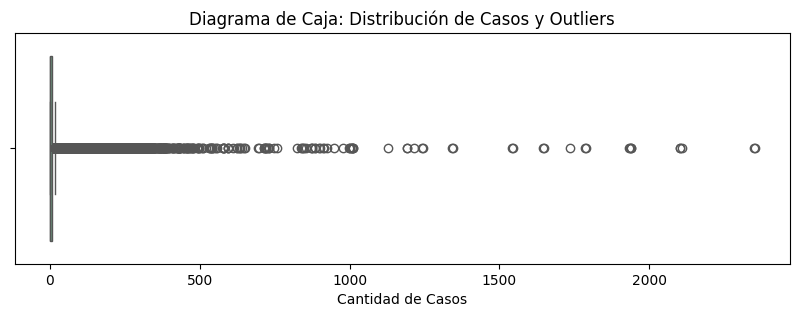

In [175]:
 #Gráfico de caja para los casos
plt.figure(figsize=(10, 3))
sns.boxplot(x=df_trabajo['cantidad_casos'], color='#6DB08A')
plt.title('Diagrama de Caja: Distribución de Casos y Outliers')
plt.xlabel('Cantidad de Casos')
plt.show()



### 6.3Matriz de Correlación de Pearson

In [176]:
correlation_matrix = df_trabajo[['anio', 'semana_epidemiologica', 'cantidad_casos']].corr(method='pearson')
display(correlation_matrix)

,anio,semana_epidemiologica,cantidad_casos
anio,1.000000,-0.171767,0.074507
semana_epidemiologica,-0.171767,1.000000,-0.051582
cantidad_casos,0.074507,-0.051582,1.000000


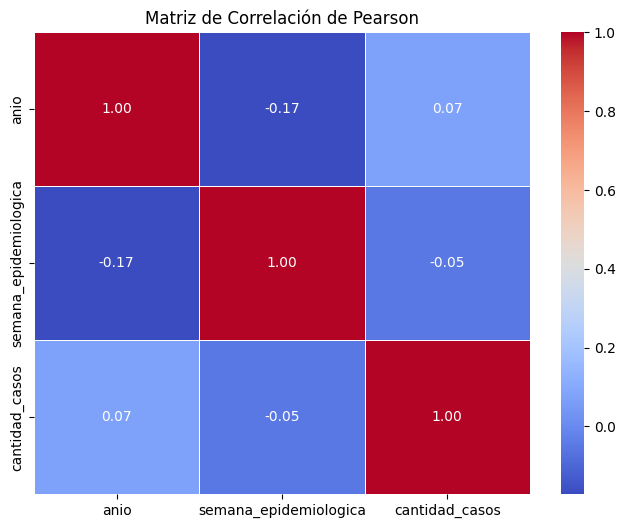

In [177]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlación de Pearson')
plt.show()

##7. Modelo de Regresión Lineal Simple (propósito: demostrar limitaciones)

### 7.1 Definición de Variables y Preparación de Datos

In [178]:
# 1. Filtrar los datos para el año 2024 (el de mayor brote según EDA)
df_2024 = df_trabajo[df_trabajo['anio'] == 2024].copy()

# 2. Definir Variable Independiente (X) y Variable Dependiente (Y)
# X debe ser un DataFrame 2D, por eso usamos [[]]
X = df_2024[['semana_epidemiologica']]
Y = df_2024['cantidad_casos']

print(f"Datos para el año 2024: {df_2024.shape[0]} filas.")
print(f"Variable Independiente (X) shape: {X.shape}")
print(f"Variable Dependiente (Y) shape: {Y.shape}")

# 3. Dividir los datos en conjuntos de entrenamiento y prueba
# Usamos un 80% para entrenamiento y un 20% para prueba
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"\nTamaño del conjunto de entrenamiento X: {X_train.shape}")
print(f"Tamaño del conjunto de prueba X: {X_test.shape}")
print(f"Tamaño del conjunto de entrenamiento Y: {Y_train.shape}")
print(f"Tamaño del conjunto de prueba Y: {Y_test.shape}")

Datos para el año 2024: 35810 filas.
Variable Independiente (X) shape: (35810, 1)
Variable Dependiente (Y) shape: (35810,)

Tamaño del conjunto de entrenamiento X: (28648, 1)
Tamaño del conjunto de prueba X: (7162, 1)
Tamaño del conjunto de entrenamiento Y: (28648,)
Tamaño del conjunto de prueba Y: (7162,)


### 7.2 Entrenamiento del Modelo de Regresión Lineal Simple

In [179]:
# Crear una instancia del modelo de regresión lineal
model_simple_lr = LinearRegression()

# Entrenar el modelo con los datos de entrenamiento
model_simple_lr.fit(X_train, Y_train)

print("Modelo de regresión lineal simple entrenado correctamente.")
print(f"Coeficiente (pendiente): {model_simple_lr.coef_[0]:.2f}")
print(f"Intercepción (ordenada al origen): {model_simple_lr.intercept_:.2f}")

Modelo de regresión lineal simple entrenado correctamente.
Coeficiente (pendiente): -0.08
Intercepción (ordenada al origen): 19.00


### 7.3 Evaluación del Modelo con Métricas

In [180]:
# Realizar predicciones sobre el conjunto de prueba
Y_pred_simple_lr = model_simple_lr.predict(X_test)

# Calcular el Error Cuadrático Medio (RMSE)
mse = mean_squared_error(Y_test, Y_pred_simple_lr)
rmse = math.sqrt(mse)

# Calcular el Coeficiente de Determinación (R-cuadrado)
r2 = r2_score(Y_test, Y_pred_simple_lr)

print(f"Predicciones realizadas correctamente.")
print(f"Error Cuadrático Medio (RMSE): {rmse:.2f}")
print(f"Coeficiente de Determinación (R-cuadrado): {r2:.2f}")

Predicciones realizadas correctamente.
Error Cuadrático Medio (RMSE): 69.81
Coeficiente de Determinación (R-cuadrado): -0.00


### 7.4 Visualización Gráfica: Datos Reales vs. Recta de Regresión

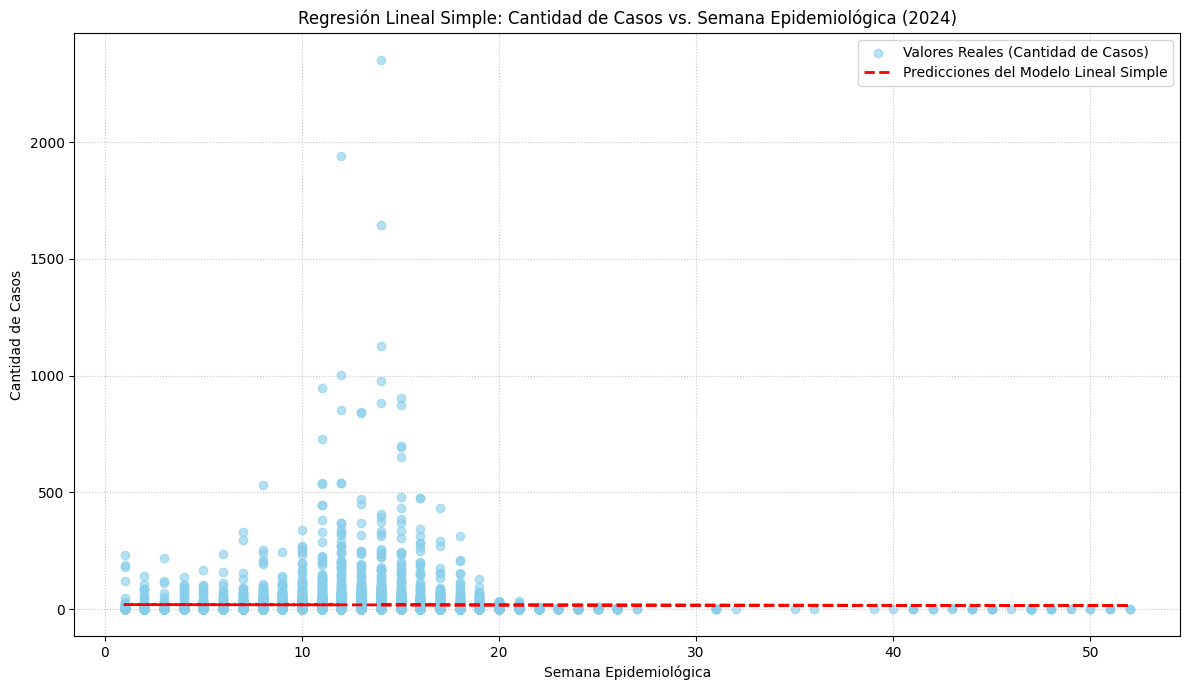

In [181]:
# Visualización de valores reales vs. predicciones del modelo lineal simple
plt.figure(figsize=(12, 7))
plt.scatter(X_test['semana_epidemiologica'], Y_test, alpha=0.6, label='Valores Reales (Cantidad de Casos)', color='skyblue')
plt.plot(X_test['semana_epidemiologica'], Y_pred_simple_lr, color='red', linestyle='--', linewidth=2, label='Predicciones del Modelo Lineal Simple')

plt.title('Regresión Lineal Simple: Cantidad de Casos vs. Semana Epidemiológica (2024)')
plt.xlabel('Semana Epidemiológica')
plt.ylabel('Cantidad de Casos')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()


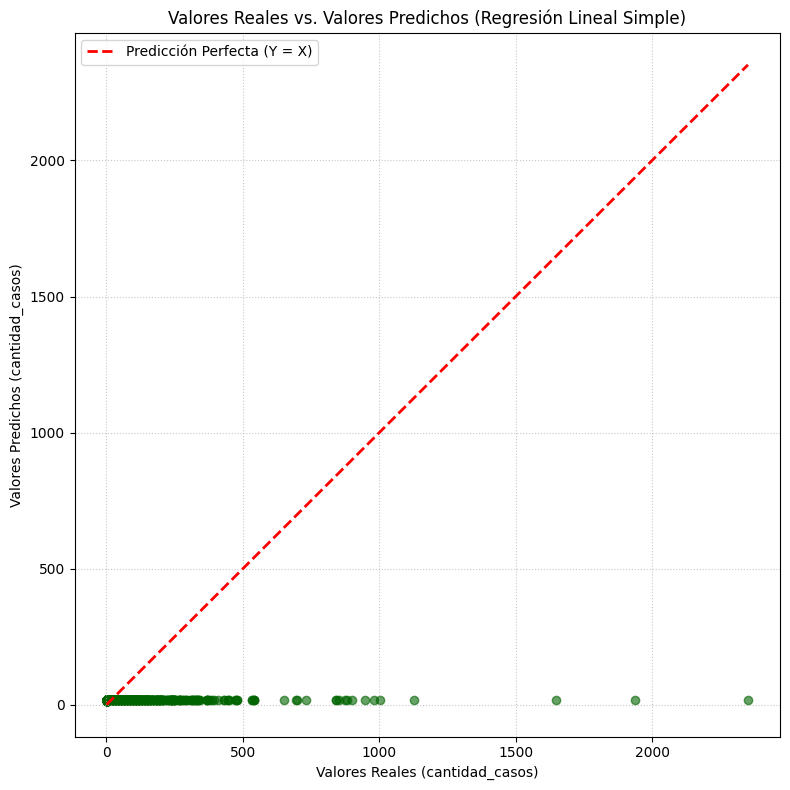

In [182]:

# Visualización de valores reales vs. valores predichos (para evaluar el ajuste)
plt.figure(figsize=(8, 8))
plt.scatter(Y_test, Y_pred_simple_lr, alpha=0.6, color='darkgreen')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2, label='Predicción Perfecta (Y = X)')
plt.title('Valores Reales vs. Valores Predichos (Regresión Lineal Simple)')
plt.xlabel('Valores Reales (cantidad_casos)')
plt.ylabel('Valores Predichos (cantidad_casos)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

### 7.5 Conclusión y limitaciones del modelo de regresión lineal simple

Como se anticipó, el modelo de regresión lineal simple muestra un rendimiento deficiente para predecir la cantidad de casos de dengue basándose únicamente en la semana epidemiológica. Esto se evidencia por:

*   **Un bajo coeficiente de determinación ($R^2$)**: Un valor de $R^2$ cercano a cero (o incluso negativo en algunos casos) indica que el modelo lineal es incapaz de explicar una proporción significativa de la variabilidad en la cantidad de casos. Es decir, la semana epidemiológica por sí sola, en un modelo lineal, no tiene una relación directa y constante con la incidencia de dengue.

*   **La naturaleza no lineal del fenómeno**: La visualización gráfica es contundente. La distribución de los casos de dengue a lo largo del año no sigue una línea recta. Por el contrario, se observa un patrón estacional y cíclico:
    *   Un aumento de casos durante los primeros meses del año (verano/otoño), coincidiendo con altas temperaturas y condiciones favorables para el mosquito Aedes aegypti.
    *   Una marcada disminución o ausencia de casos durante los meses de invierno.
    *   Posibles rebrotes o incrementos hacia finales de año o principios del siguiente, al volver las temperaturas cálidas.

*   **Incapacidad de una recta para capturar ciclos biológicos/climatológicos**: Un modelo lineal asume una relación directamente proporcional y constante entre la variable independiente y la dependiente. Este supuesto es fundamentalmente incorrecto para fenómenos como el dengue, donde la transmisión está intrínsecamente ligada a factores ambientales y biológicos que operan en ciclos anuales (temperatura, lluvias, población de mosquitos, etc.). Una línea recta no puede representar adecuadamente las fases de ascenso, pico y descenso que caracterizan a los brotes de enfermedades estacionales.
